In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Descripton:

- date — the specific day when the search data was recorded
- query — the keyword a user typed in Google to find the website
- page — the exact URL on eduminatti.com that appeared in search results
- clicks — how many times users actually clicked on that page from Google
- impressions — how many times that page was shown in Google search results
- ctr — Click Through Rate, percentage of people who clicked after seeing the result
- position — average ranking position on Google for that keyword that day (lower = better)

In [ ]:
df=pd.read_csv('SEO_data.csv')
df.head()

,date,query,page,clicks,impressions,ctr,position
0,2024-01-01,ielts coaching near me,https://www.eduminatti.com/study-in-canada,0,7,0.57,30.1
1,2024-01-01,study abroad consultants in india,https://www.eduminatti.com/study-in-australia,5,184,3.19,12.8
2,2024-01-01,education consultancy fees,https://www.eduminatti.com/study-in-australia,0,49,1.86,36.2
3,2024-01-01,top engineering colleges abroad,https://www.eduminatti.com/study-in-australia,0,22,2.52,23.3
4,2024-01-01,new zealand student visa,https://www.eduminatti.com/,0,15,2.25,38.3


In [53]:
df.tail()

,date,query,page,clicks,impressions,ctr,position
1372,2024-06-30,pte coaching classes,https://www.eduminatti.com/student-visa,0,12,1.54,35.6
1373,2024-06-30,usa student visa f1,https://www.eduminatti.com/student-visa,0,38,2.62,31.3
1374,2024-06-30,scholarship for indian students abroad,https://www.eduminatti.com/study-in-uk,0,17,2.49,25.9
1375,2024-06-30,abroad education loan india,https://www.eduminatti.com/study-in-canada,5,63,9.46,7.2
1376,2024-06-30,ielts coaching near me,https://www.eduminatti.com/study-in-germany,6,63,9.87,7.6


In [54]:
print(df.shape)

(1377, 7)


In [55]:
df.isnull().sum()

date           0
query          0
page           0
clicks         0
impressions    0
ctr            0
position       0
dtype: int64

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1377 non-null   str    
 1   query        1377 non-null   str    
 2   page         1377 non-null   str    
 3   clicks       1377 non-null   int64  
 4   impressions  1377 non-null   int64  
 5   ctr          1377 non-null   float64
 6   position     1377 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 178.6 KB


In [57]:
df['query'].unique()

<ArrowStringArray>
[                         'ielts coaching near me',
               'study abroad consultants in india',
                      'education consultancy fees',
                 'top engineering colleges abroad',
                        'new zealand student visa',
                        'student visa canada 2024',
                             'usa student visa f1',
 'best universities in canada for indian students',
                   'germany education consultants',
                 'study in uk for indian students',
                          'mba abroad consultants',
                    'best country to study abroad',
                       'free education in germany',
                    'australia study visa process',
                            'pte coaching classes',
          'scholarship for indian students abroad',
                     'abroad education loan india',
                    'uk student visa requirements',
                  'masters in data science ab

In [58]:
df.tail()

,date,query,page,clicks,impressions,ctr,position
1372,2024-06-30,pte coaching classes,https://www.eduminatti.com/student-visa,0,12,1.54,35.6
1373,2024-06-30,usa student visa f1,https://www.eduminatti.com/student-visa,0,38,2.62,31.3
1374,2024-06-30,scholarship for indian students abroad,https://www.eduminatti.com/study-in-uk,0,17,2.49,25.9
1375,2024-06-30,abroad education loan india,https://www.eduminatti.com/study-in-canada,5,63,9.46,7.2
1376,2024-06-30,ielts coaching near me,https://www.eduminatti.com/study-in-germany,6,63,9.87,7.6


In [60]:
# top performing keywords
df.groupby('query')['clicks'].sum().sort_values(ascending=False).head(10)

query
top engineering colleges abroad    956
study in canada after 12th         869
abroad education loan india        812
pte coaching classes               748
best country to study abroad       741
new zealand student visa           702
uk student visa requirements       512
study in uk for indian students    495
ielts coaching near me             488
education consultancy fees         375
Name: clicks, dtype: int64

In [61]:
#best performing web pages
df.groupby('page')['position'].mean().sort_values()

page
https://www.eduminatti.com/student-visa          23.830435
https://www.eduminatti.com/study-in-australia    24.238776
https://www.eduminatti.com/ielts-coaching        24.310256
https://www.eduminatti.com/study-in-canada       25.190441
https://www.eduminatti.com/study-in-germany      25.221849
https://www.eduminatti.com/study-in-uk           25.386452
https://www.eduminatti.com/about-us              25.615942
https://www.eduminatti.com/                      26.090598
https://www.eduminatti.com/study-in-usa          26.742636
https://www.eduminatti.com/scholarships          28.045070
Name: position, dtype: float64

In [62]:
#avg monthly ctr
df['month'] = pd.to_datetime(df['date']).dt.month
df.groupby('month')['ctr'].mean()

month
1    3.522078
2    4.550981
3    3.937269
4    3.602771
5    3.803616
6    3.349494
Name: ctr, dtype: float64

In [63]:
# Total clicks and impressions by month
df.groupby('month')[['clicks','impressions']].sum()

,clicks,impressions
month,,
1,1137,15658
2,2375,21572
3,1787,18264
4,1411,17403
5,1489,17760
6,1161,16215


In [64]:
# Best CTR keywords (high click rate)
df.groupby('query')['ctr'].mean().sort_values(ascending=False).head(10).round(2)


query
abroad education loan india        5.21
top engineering colleges abroad    4.52
study in canada after 12th         4.40
best country to study abroad       4.35
new zealand student visa           4.28
pte coaching classes               4.14
ielts coaching near me             3.87
uk student visa requirements       3.84
education consultancy fees         3.78
study in uk for indian students    3.69
Name: ctr, dtype: float64

In [65]:
#worse ranking keywords
df.groupby('query')['position'].mean().sort_values(ascending=False).head(5).round(1)

query
scholarship for indian students abroad             28.8
free education in germany                          28.1
best universities in canada for indian students    27.3
germany education consultants                      27.0
study abroad consultants in india                  26.6
Name: position, dtype: float64

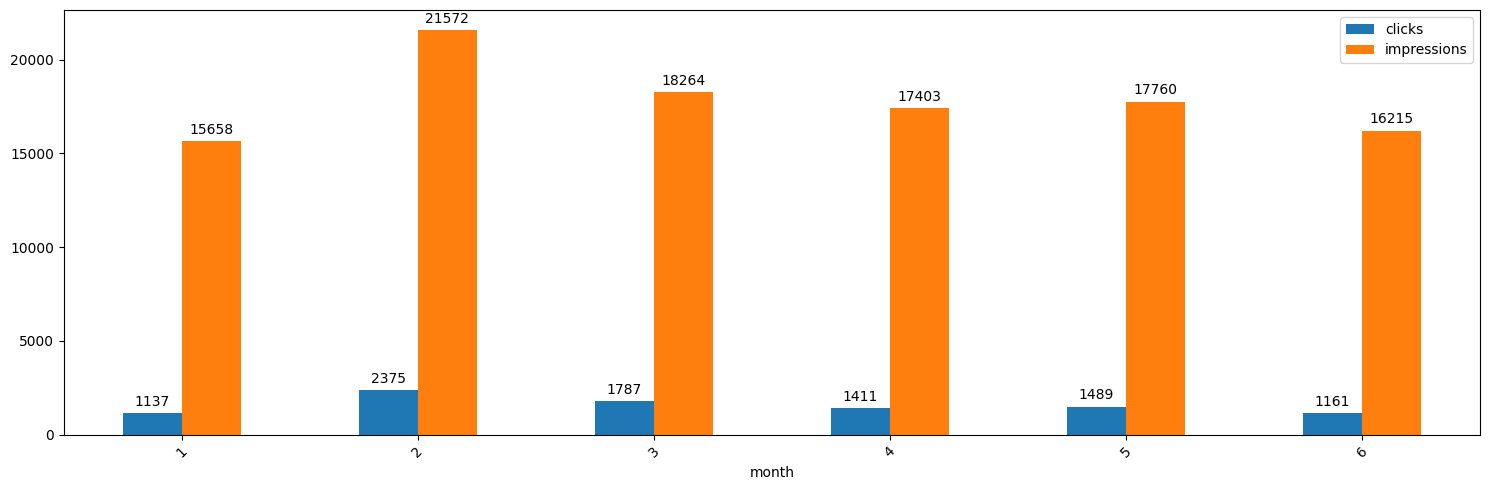

In [ ]:
#click and Impression comparision bar chart
ax = df.groupby('month')[['clicks','impressions']].sum().plot(
    kind='bar',
    figsize=(15,5)
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

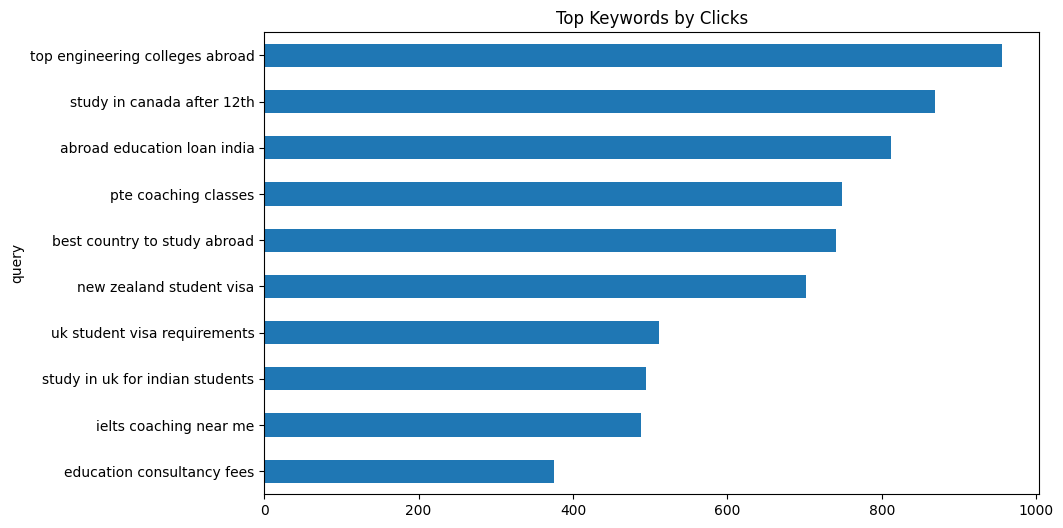

In [66]:
# Top 10 keywords by clicks - horizontal bar chart
df.groupby('query')['clicks'].sum().sort_values().tail(10).plot(kind='barh', figsize=(10,6), title='Top Keywords by Clicks')
plt.show()

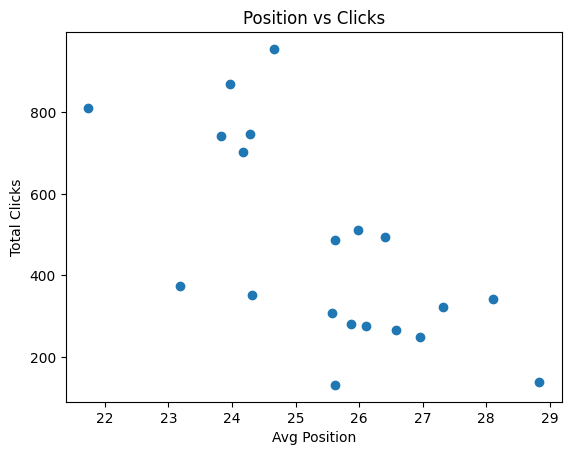

In [67]:
# 4. Position vs Clicks scatter plot
query_stats = df.groupby('query').agg({'clicks':'sum','position':'mean'}).reset_index()
plt.scatter(query_stats['position'], query_stats['clicks'])
plt.xlabel('Avg Position')
plt.ylabel('Total Clicks')
plt.title('Position vs Clicks')
plt.show()

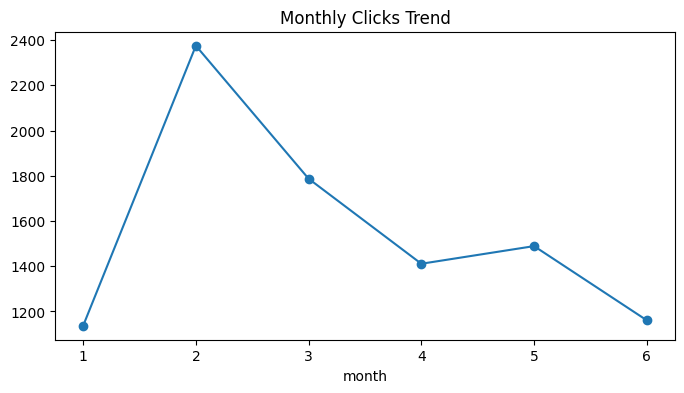

In [68]:
#  Monthly clicks trend
df['month'] = pd.to_datetime(df['date']).dt.month
df.groupby('month')['clicks'].sum().plot(kind='line', marker='o', figsize=(8,4), title='Monthly Clicks Trend')
plt.show()

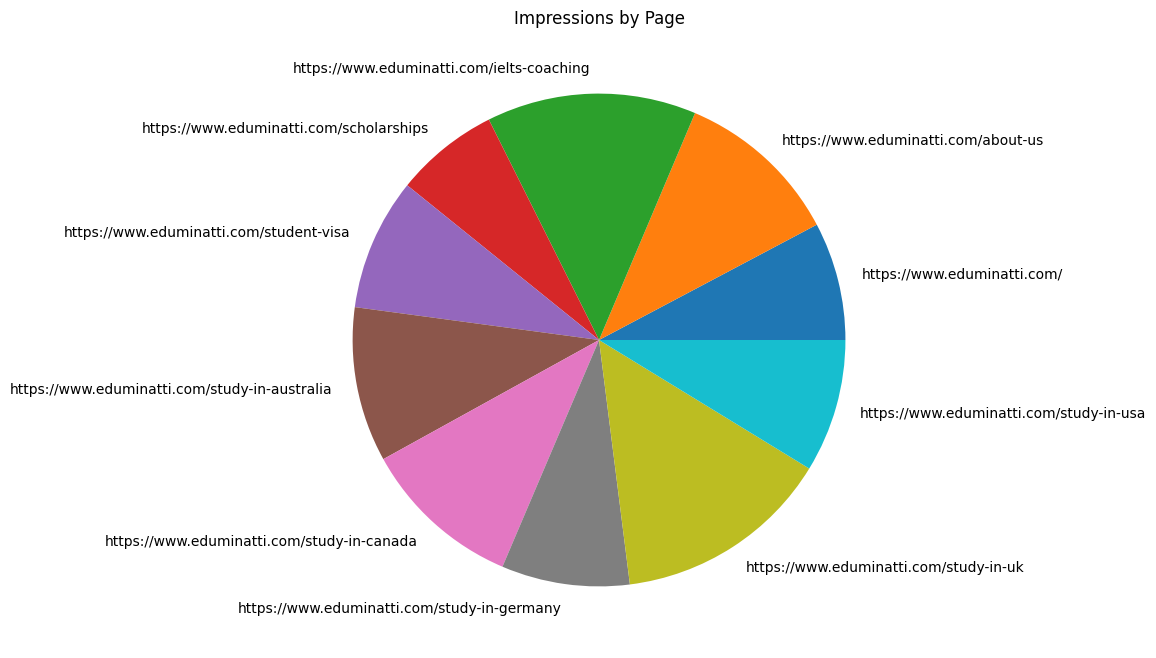

In [69]:
# Impressions by page - pie chart
df.groupby('page')['impressions'].sum().plot(kind='pie', figsize=(8,8), title='Impressions by Page')
plt.show()

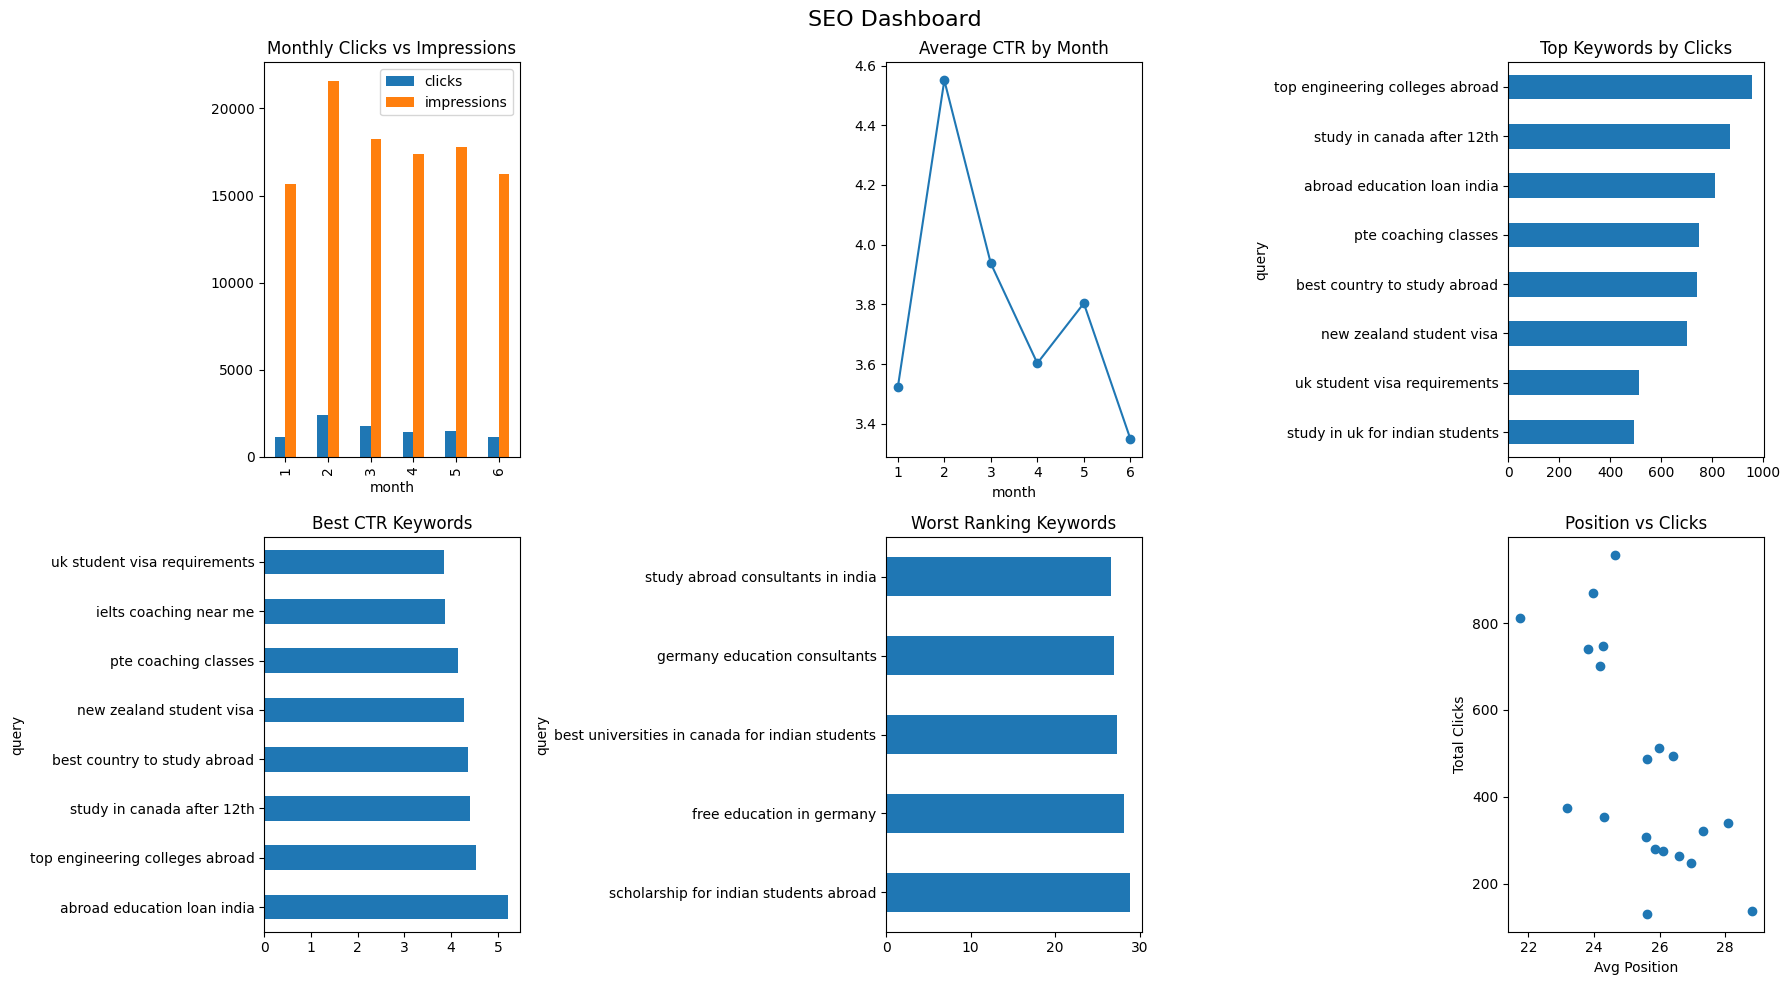

In [ ]:
#compiled charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SEO Dashboard', fontsize=16)

# Chart 1 - Monthly Clicks vs Impressions
monthly = df.groupby('month')[['clicks','impressions']].sum()
monthly.plot(kind='bar', ax=axes[0,0], title='Monthly Clicks vs Impressions')

# Chart 2 - Monthly CTR
df.groupby('month')['ctr'].mean().plot(kind='line', marker='o', ax=axes[0,1], title='Average CTR by Month')

# Chart 3 - Top Keywords by Clicks
df.groupby('query')['clicks'].sum().sort_values().tail(8).plot(kind='barh', ax=axes[0,2], title='Top Keywords by Clicks')

# Chart 4 - Best CTR Keywords
df.groupby('query')['ctr'].mean().sort_values(ascending=False).head(8).plot(kind='barh', ax=axes[1,0], title='Best CTR Keywords')

# Chart 5 - Worst Ranking Keywords
df.groupby('query')['position'].mean().sort_values(ascending=False).head(5).plot(kind='barh', ax=axes[1,1], title='Worst Ranking Keywords')

# Chart 6 - Position vs Clicks
query_stats = df.groupby('query').agg({'clicks':'sum','position':'mean'}).reset_index()
axes[1,2].scatter(query_stats['position'], query_stats['clicks'])
axes[1,2].set_xlabel('Avg Position')
axes[1,2].set_ylabel('Total Clicks')
axes[1,2].set_title('Position vs Clicks')

plt.tight_layout()
plt.savefig('seo_analysis.png', dpi=150)
plt.show()